<a href="https://colab.research.google.com/github/yazan-95/PythonUniversityUseOf/blob/main/Project_Mnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from sklearn.datasets import fetch_openml
import numpy as np

In [2]:
mnist =fetch_openml("mnist_784" , version=1)
mnist.keys()

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])

In [3]:
x = mnist["data"]

In [4]:
x

,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
69998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
y = mnist["target"]
y

,class
0,5
1,0
2,4
3,1
4,9
...,...
69995,2
69996,3
69997,4
69998,5


In [6]:
import matplotlib.pyplot as plt
import matplotlib as mpl

In [7]:
y.dtype

CategoricalDtype(categories=['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'], ordered=False, categories_dtype=object)

In [8]:
y= y.astype(np.uint8)

In [9]:
y

,class
0,5
1,0
2,4
3,1
4,9
...,...
69995,2
69996,3
69997,4
69998,5


In [10]:
x_train , x_test , y_train , y_test = x[:60000], x[60000:],y[:60000],y[60000:]

In [11]:
y_test

,class
60000,7
60001,2
60002,1
60003,0
60004,4
...,...
69995,2
69996,3
69997,4
69998,5


In [12]:
y_train_5 = (y_train==5)

In [13]:
y_test_5 =(y_test ==5)

y_train_5

,class
0,True
1,False
2,False
3,False
4,False
...,...
59995,False
59996,False
59997,True
59998,False


In [14]:
from sklearn.linear_model import SGDClassifier

In [15]:
sgd_clf = SGDClassifier(random_state=42)

sgd_clf.fit(x_train,y_train_5)

SGDClassifier(random_state=42)

In [16]:
sample = np.array([x_train.iloc[59997]])

sgd_clf.predict(sample)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(


array([ True])

In [17]:
from sklearn.model_selection import cross_val_score

cross_val_score(sgd_clf, x_train,y_train_5, cv =3 , scoring="accuracy")

array([0.95035, 0.96035, 0.9604 ])

In [18]:
from sklearn.base import BaseEstimator

class Never5Classifier(BaseEstimator):

    def fit(self,X,y):
        pass

    def predict(self,X):
        return np.zeros((len(X),1),dtype=bool)

dump = Never5Classifier()
cross_val_score(dump, x_train,y_train_5, cv =3 , scoring="accuracy")



array([0.91125, 0.90855, 0.90915])

In [19]:
from sklearn.model_selection import cross_val_predict

y_train_pred = cross_val_predict(sgd_clf,x_train,y_train_5,cv=3)

In [20]:
y_train_pred.shape

(60000,)

In [21]:
from sklearn.metrics import confusion_matrix

In [22]:
confusion_matrix(y_train_5,y_train_pred)

array([[53892,   687],
       [ 1891,  3530]])

In [23]:
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score


In [24]:
precision_score(y_train_5,y_train_pred)

0.8370879772350012

In [25]:
recall_score(y_train_5,y_train_pred)

0.6511713705958311

In [26]:
sgd_clf.fit(x_train,y_train)

SGDClassifier(random_state=42)

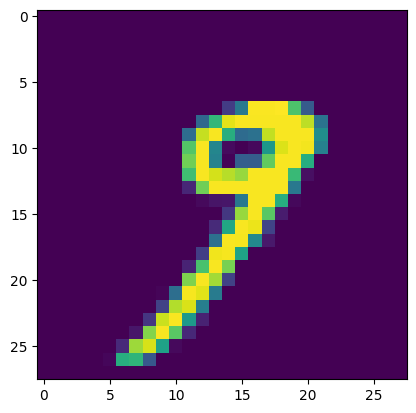

In [27]:
some_digit = np.array(x.loc[33])
some_digit_image = some_digit.reshape(28,28)
plt.imshow(some_digit_image)

In [28]:
sgd_clf.predict([some_digit])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(


array([3], dtype=uint8)

In [29]:
sgd_clf.classes_

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [30]:
from sklearn.ensemble import RandomForestClassifier

In [31]:
forest_clf = RandomForestClassifier(random_state=42)

In [32]:
forest_clf.fit(x_train,y_train)

RandomForestClassifier(random_state=42)

In [33]:
forest_clf.predict([some_digit])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array([9], dtype=uint8)

In [34]:
cross_val_score(forest_clf, x_train,y_train, cv =3 , scoring="accuracy")

array([0.9646 , 0.96255, 0.9666 ])

In [35]:
forest_clf.predict_proba([some_digit])

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


array([[0.  , 0.  , 0.01, 0.01, 0.03, 0.  , 0.  , 0.06, 0.01, 0.88]])

In [36]:
some_digit.mean()

np.float64(27.007653061224488)

In [37]:
from sklearn.preprocessing import StandardScaler

In [38]:
scalar = StandardScaler()

In [39]:
x_train_scaled = scalar.fit_transform(x_train)

In [40]:
forest_clf.fit(x_train_scaled,y_train)

RandomForestClassifier(random_state=42)

In [41]:
cross_val_score(forest_clf, x_train_scaled,y_train, cv =3 , scoring="accuracy")

array([0.96445, 0.96255, 0.96645])

In [42]:
cross_val_score(sgd_clf, x_train_scaled,y_train, cv =3 , scoring="accuracy")

array([0.8983, 0.891 , 0.9018])